# visit_registry.py

In [20]:
"""Keeps visited indexes in check."""
import numpy as np
import random


class VisitRegistry:
    """A straightforward visit array implementation."""

    def __init__(self, capacity=0):
        """Constructor."""
        self.remaining = set()
        for num in range(capacity):
            self.remaining.add(num)

    def get_unvisited_count(self):
        """An unvisited count getter."""
        return len(self.remaining)

    def mark_visited(self, index):
        """Set a single index as visited."""
        self.remaining.discard(index)

    def mark_visited_range(self, start, stop):
        """Set a range as visited."""
        for i in range(start, stop):
            self.mark_visited(i)

    def get_next_unvisited(self):
        """Next unvisited entry."""
        if self.get_unvisited_count() == 0:
            return np.nan

        return random.choice(tuple(self.remaining))

    def clone(self):
        """Make the array's copy."""
        clone = VisitRegistry()
        clone.remaining = self.remaining.copy()
        return clone

# distance.py

In [21]:
"""Distance computation."""
import numpy as np


def euclidean(a, b):
    """Compute a Euclidean distance value."""
    return np.sqrt(np.sum((a-b)**2))


def early_abandoned_euclidean(a, b, upper_limit):
    """Compute a Euclidean distance value in early abandoning fashion."""
    lim = upper_limit * upper_limit
    res = 0.
    for i in range(0, len(a)):
        res += np.dot((a[i]-b[i]), (a[i]-b[i]))
        if res > lim:
            return np.nan
    return np.sqrt(res)

# znorm.py

In [22]:
"""Implements znorm."""

from __future__ import division
import numpy as np
from scipy.linalg import sqrtm
from scipy.linalg import inv


def l2norm(array):
    """
    :param array: numpy array
    :return: non-negative real indicating the L2-norm of the array.

    >>> '%0.2f' % l2norm(np.array([1, 2, 3]))
    '3.74'
    >>> '%0.2f' % l2norm(np.array([1, 2, 3])[1])
    '2.00'
    >>> '%0.2f' % l2norm(np.array([1, 2, 3])[1:])
    '3.61'
    """

    return np.sqrt(np.sum(np.square(array)))


def znorm(series, znorm_threshold=0.01):
    """Znorm implementation.

    >>> print ['{:0.2f}'.format(x) for x in znorm([1, 2, 3])]
    ['-1.22', '0.00', '1.22']
    >>> print ['{:0.2f}'.format(x) for x in znorm([3, 2, 1])]
    ['1.22', '0.00', '-1.22']
    >>> print ['{:0.2f}'.format(x) for x in znorm([1, 2])]
    ['-1.00', '1.00']
    >>> print ['{:0.2f}'.format(x) for x in np.sum(znorm([[1, 2, 3], [6, 5, 4]]), axis=0)]
    ['0.00', '0.00', '0.00']
    >>> znorm([[1, 2, 3], [6, 5, 4]])
    array([[-1., -1., -1.],
           [ 1.,  1.,  1.]])
    """

    series = np.array(series)
    original_series_shape = series.shape
    is_multidimensional = (len(series.shape) > 1) and (series.shape[1] > 1)
    mu = np.average(series, axis=0)
    C = np.cov(series, bias=True, rowvar=not is_multidimensional)

    # Only update those subsequences with variance over the threshold.
    if is_multidimensional:
        series = series - mu
        C = np.diagonal(C)
        indexes = (C >= np.square(znorm_threshold))
        series[:, indexes] = (series[:, indexes] / np.sqrt(C[indexes]))
    else:
        series = series - mu
        if C >= np.square(znorm_threshold):
            series /= np.sqrt(C)

    # Check on shape returned.
    assert(series.shape == original_series_shape)

    return series

# discord.py

In [23]:
"""Discord discovery routines."""
import numpy as np
#from .visit_registry import VisitRegistry
#from .distance import early_abandoned_euclidean
#from .znorm import znorm


def find_discords_brute_force(series, win_size, num_discords=2, znorm_threshold=0.01):
    """Early-abandoned distance-based discord discovery."""
    discords = list()

    globalRegistry = VisitRegistry(len(series) - win_size + 1)
    znorms = np.array([znorm(series[pos: pos + win_size], znorm_threshold) for pos in range(len(series) - win_size + 1)])

    while len(discords) < num_discords:

        bestDiscord = find_best_discord_brute_force(series, win_size,
                                                    globalRegistry,
                                                    znorms)

        if -1 == bestDiscord[0]:
            break

        discords.append(bestDiscord)

        mark_start = max(0, bestDiscord[0] - win_size + 1)
        mark_end = bestDiscord[0] + win_size

        globalRegistry.mark_visited_range(mark_start, mark_end)

    return discords


def find_best_discord_brute_force(series, win_size, global_registry, znorms):
    """Early-abandoned distance-based discord discovery."""
    best_so_far_distance = -1.0
    best_so_far_index = -1

    outer_registry = global_registry.clone()

    outer_idx = outer_registry.get_next_unvisited()

    while ~np.isnan(outer_idx):

        outer_registry.mark_visited(outer_idx)

        candidate_seq = znorms[outer_idx]

        nn_distance = np.inf
        inner_registry = VisitRegistry(len(series) - win_size + 1)

        inner_idx = inner_registry.get_next_unvisited()

        while ~np.isnan(inner_idx):
            inner_registry.mark_visited(inner_idx)

            if abs(inner_idx - outer_idx) >= win_size:

                curr_seq = znorms[inner_idx]

                dist = early_abandoned_euclidean(candidate_seq, curr_seq, nn_distance)

                if (~np.isnan(dist)) and (dist < nn_distance):
                    nn_distance = dist

            inner_idx = inner_registry.get_next_unvisited()

        if ~(np.inf == nn_distance) and (nn_distance > best_so_far_distance):
            best_so_far_distance = nn_distance
            best_so_far_index = outer_idx

        outer_idx = outer_registry.get_next_unvisited()

    return best_so_far_index, best_so_far_distance

# strfunc.py

In [24]:
"""Convert a normlized timeseries to SAX symbols."""


def idx2letter(idx):
    """Convert a numerical index to a char."""
    if 0 <= idx < 20:
        return chr(97 + idx)
    else:
        raise ValueError('A wrong idx value supplied.')

# paa.py

In [25]:
"""Implements PAA."""
from __future__ import division
import numpy as np


def paa(series, paa_segment_size, sax_type='unidim'):
    """PAA implementation.

    >>> paa([1, 2, 3], 3, 'unidim')
    array([1., 2., 3.])
    >>> paa([1, 2, 3], 1, 'unidim')
    array([2.])
    >>> paa([4, 3, 8, 5], 1, 'unidim')
    array([5.])
    >>> paa([[1, 2, 3], [6, 5, 4]], 1, 'repeat')
    array([[3.5, 3.5, 3.5]])
    >>> paa([[1, 2, 3], [6, 5, 4]], 2, 'repeat')
    array([[1., 2., 3.],
           [6., 5., 4.]])
    """

    series = np.array(series)
    series_len = series.shape[0]

    if sax_type in ['repeat', 'energy']:
        num_dims = series.shape[1]
    else:
        num_dims = 1
        is_multidimensional = (len(series.shape) > 1) and (series.shape[1] > 1)
        if not is_multidimensional:
            series = series.reshape(series.shape[0], 1)

    res = np.zeros((num_dims, paa_segment_size))

    for dim in range(num_dims):
        # Check if we can evenly divide the series.
        if series_len % paa_segment_size == 0:
            inc = series_len // paa_segment_size

            for i in range(0, series_len):
                idx = i // inc
                np.add.at(res[dim], idx, np.mean(series[i][dim]))
            res[dim] /= inc
        # Process otherwise.
        else:
            for i in range(0, paa_segment_size * series_len):
                idx = i // series_len
                pos = i // paa_segment_size
                np.add.at(res[dim], idx, np.mean(series[pos][dim]))
            res[dim] /= series_len

    if sax_type in ['repeat', 'energy']:
        return res.T
    else:
        return res.flatten()

# alphabet.py

In [26]:
"""Implements Alphabet cuts."""
import numpy as np


def cuts_for_asize(a_size):
    """Generate a set of alphabet cuts for its size."""
    """ Typically, we generate cuts in R as follows:
        get_cuts_for_num <- function(num) {
        cuts = c(-Inf)
        for (i in 1:(num-1)) {
            cuts = c(cuts, qnorm(i * 1/num))
            }
            cuts
        }

        get_cuts_for_num(3) """
    options = {
        2: np.array([-np.inf,  0.00]),
        3: np.array([-np.inf, -0.4307273, 0.4307273]),
        4: np.array([-np.inf, -0.6744898, 0, 0.6744898]),
        5: np.array([-np.inf, -0.841621233572914, -0.2533471031358,
                    0.2533471031358, 0.841621233572914]),
        6: np.array([-np.inf, -0.967421566101701, -0.430727299295457, 0,
                    0.430727299295457, 0.967421566101701]),
        7: np.array([-np.inf, -1.06757052387814, -0.565948821932863,
                    -0.180012369792705, 0.180012369792705, 0.565948821932863,
                    1.06757052387814]),
        8: np.array([-np.inf, -1.15034938037601, -0.674489750196082,
                    -0.318639363964375, 0, 0.318639363964375,
                    0.674489750196082, 1.15034938037601]),
        9: np.array([-np.inf, -1.22064034884735, -0.764709673786387,
                    -0.430727299295457, -0.139710298881862, 0.139710298881862,
                    0.430727299295457, 0.764709673786387, 1.22064034884735]),
        10: np.array([-np.inf, -1.2815515655446, -0.841621233572914,
                     -0.524400512708041, -0.2533471031358, 0, 0.2533471031358,
                     0.524400512708041, 0.841621233572914, 1.2815515655446]),
        11: np.array([-np.inf, -1.33517773611894, -0.908457868537385,
                     -0.604585346583237, -0.348755695517045,
                     -0.114185294321428, 0.114185294321428, 0.348755695517045,
                     0.604585346583237, 0.908457868537385, 1.33517773611894]),
        12: np.array([-np.inf, -1.38299412710064, -0.967421566101701,
                     -0.674489750196082, -0.430727299295457,
                     -0.210428394247925, 0, 0.210428394247925,
                     0.430727299295457, 0.674489750196082, 0.967421566101701,
                     1.38299412710064]),
        13: np.array([-np.inf, -1.42607687227285, -1.0200762327862,
                     -0.736315917376129, -0.502402223373355,
                     -0.293381232121193, -0.0965586152896391,
                     0.0965586152896394, 0.293381232121194, 0.502402223373355,
                     0.73631591737613, 1.0200762327862, 1.42607687227285]),
        14: np.array([-np.inf, -1.46523379268552, -1.06757052387814,
                     -0.791638607743375, -0.565948821932863, -0.36610635680057,
                     -0.180012369792705, 0, 0.180012369792705,
                     0.36610635680057, 0.565948821932863, 0.791638607743375,
                     1.06757052387814, 1.46523379268552]),
        15: np.array([-np.inf, -1.50108594604402, -1.11077161663679,
                     -0.841621233572914, -0.622925723210088,
                     -0.430727299295457, -0.2533471031358, -0.0836517339071291,
                     0.0836517339071291, 0.2533471031358, 0.430727299295457,
                     0.622925723210088, 0.841621233572914, 1.11077161663679,
                     1.50108594604402]),
        16: np.array([-np.inf, -1.53412054435255, -1.15034938037601,
                     -0.887146559018876, -0.674489750196082,
                     -0.488776411114669, -0.318639363964375,
                     -0.157310684610171, 0, 0.157310684610171,
                     0.318639363964375, 0.488776411114669, 0.674489750196082,
                     0.887146559018876, 1.15034938037601, 1.53412054435255]),
        17: np.array([-np.inf, -1.5647264713618, -1.18683143275582,
                     -0.928899491647271, -0.721522283982343,
                     -0.541395085129088, -0.377391943828554,
                     -0.223007830940367, -0.0737912738082727,
                     0.0737912738082727, 0.223007830940367, 0.377391943828554,
                     0.541395085129088, 0.721522283982343, 0.928899491647271,
                     1.18683143275582, 1.5647264713618]),
        18: np.array([-np.inf, -1.59321881802305, -1.22064034884735,
                     -0.967421566101701, -0.764709673786387,
                     -0.589455797849779, -0.430727299295457,
                     -0.282216147062508, -0.139710298881862, 0,
                     0.139710298881862, 0.282216147062508, 0.430727299295457,
                     0.589455797849779, 0.764709673786387, 0.967421566101701,
                     1.22064034884735, 1.59321881802305]),
        19: np.array([-np.inf, -1.61985625863827, -1.25211952026522,
                     -1.00314796766253, -0.8045963803603, -0.633640000779701,
                     -0.47950565333095, -0.336038140371823, -0.199201324789267,
                     -0.0660118123758407, 0.0660118123758406,
                     0.199201324789267, 0.336038140371823, 0.47950565333095,
                     0.633640000779701, 0.8045963803603, 1.00314796766253,
                     1.25211952026522, 1.61985625863827]),
        20: np.array([-np.inf, -1.64485362695147, -1.2815515655446,
                     -1.03643338949379, -0.841621233572914, -0.674489750196082,
                     -0.524400512708041, -0.385320466407568, -0.2533471031358,
                     -0.125661346855074, 0, 0.125661346855074, 0.2533471031358,
                     0.385320466407568, 0.524400512708041, 0.674489750196082,
                     0.841621233572914, 1.03643338949379, 1.2815515655446,
                     1.64485362695147]),
    }

    return options[a_size]

# sax.py

In [27]:
"""Converts a normlized timeseries to SAX symbols."""
from collections import defaultdict
#from .strfunc import idx2letter
#from .znorm import znorm
#from .paa import paa
#from .alphabet import cuts_for_asize
import numpy as np
from sklearn.cluster import KMeans


# For SAX-REPEAT.
def get_sax_list(series, cuts):
    """
    >>> get_sax_list([[1, 2, -3], [4, 9, -2], [5, 7, -8], [0, 3, -1], [-1, -2, -10]], cuts_for_asize(3))
    [[2, 2, 0], [2, 2, 0], [2, 2, 0], [1, 2, 0], [0, 0, 0]]
    """

    series = np.array(series)
    a_size = len(cuts)
    multidim_sax_list = []

    for i in range(series.shape[0]):
        multidim_sax = []

        for j in range(series.shape[1]):
            num = series[i][j]

            # If the number is below 0, start from the bottom, otherwise from the top
            if num >= 0:
                j = a_size - 1
                while j > 0 and cuts[j] >= num:
                    j = j - 1
                multidim_sax.append(j)
            else:
                j = 1
                while j < a_size and cuts[j] <= num:
                    j = j + 1
                multidim_sax.append(j - 1)

        multidim_sax_list.append(multidim_sax)

    return multidim_sax_list


def ts_to_string(series, cuts):
    """A straightforward num-to-string conversion.

    >>> ts_to_string([-1, 0, 1], cuts_for_asize(3))
    'abc'

    >>> ts_to_string([1, -1, 1], cuts_for_asize(3))
    'cac'
    """

    series = np.array(series)
    a_size = len(cuts)
    sax = list()

    for i in range(series.shape[0]):
        num = series[i]

        # If the number is below 0, start from the bottom, otherwise from the top
        if num >= 0:
            j = a_size - 1
            while j > 0 and cuts[j] >= num:

                j = j - 1
            sax.append(idx2letter(j))
        else:
            j = 1
            while j < a_size and cuts[j] <= num:
                j = j + 1
            sax.append(idx2letter(j-1))

    return ''.join(sax)


def is_mindist_zero(a, b):
    """Check mindist."""
    if len(a) != len(b):
        return 0
    else:
        for i in range(0, len(b)):
            if abs(ord(a[i]) - ord(b[i])) > 1:
                return 0
    return 1


def sax_by_chunking(series, paa_size, alphabet_size=3, znorm_threshold=0.01):
    """Simple chunking conversion implementation."""
    paa_rep = paa(znorm(series, znorm_threshold), paa_size)
    cuts = cuts_for_asize(alphabet_size)
    return ts_to_string(paa_rep, cuts)


def sax_via_window(series, win_size, paa_size, alphabet_size=3,
                   nr_strategy='exact', znorm_threshold=0.01, sax_type='unidim'):
    """Simple via window conversion implementation.

    # SAX-ENERGY
    >>> sax_via_window([[1, 2, 3], [4, 5, 6]], win_size=1, paa_size=3, sax_type='energy', nr_strategy=None)['abc']
    [0, 1]

    >>> sax_via_window([[1, 2, 3, 4], [4, 5, 6, 7]], win_size=1, paa_size=4, sax_type='energy', nr_strategy=None)['aacc']
    [0, 1]

    >>> sax_via_window([[1, 2, 3, 4], [4, 5, 6, 7]], win_size=2, paa_size=4, sax_type='energy', nr_strategy=None)['aaccaacc']
    [0]

    # SAX-REPEAT
    >>> sax_via_window([[1, 2, 3], [4, 5, 6], [7, 8, 9]], win_size=2, paa_size=2, sax_type='repeat', nr_strategy=None)['ab']
    [0, 1]

    >>> sax_via_window([[1, 2, 3], [4, 5, 6], [7, 8, 9]], win_size=1, paa_size=1, sax_type='repeat', nr_strategy=None)['a']
    [0, 1, 2]

    # SAX-INDEPENDENT
    >>> sax_via_window([[1, 2, 3, 4], [4, 5, 6, 7]], win_size=2, paa_size=2, sax_type='independent', nr_strategy=None)['acacacac']
    [0]

    >>> sax_via_window([[1, 2], [4, 5], [7, 8]], win_size=2, paa_size=2, sax_type='independent', nr_strategy=None)['acac']
    [0, 1]

    >>> sax_via_window([[1, 2], [4, 8], [7, 5]], win_size=2, paa_size=2, sax_type='independent', nr_strategy=None)['acac']
    [0]

    >>> sax_via_window([[1, 2], [4, 8], [7, 5]], win_size=2, paa_size=2, sax_type='independent', nr_strategy=None)['acca']
    [1]

    """

    # Convert to numpy array.
    series = np.array(series)

    # Check on dimensions.
    if len(series.shape) > 2:
        raise ValueError('Please reshape time-series to stack dimensions along the 2nd dimension, so that the array shape is a 2-tuple.')

    # PAA size is the length of the PAA sequence.
    if sax_type != 'energy' and paa_size > win_size:
        raise ValueError('PAA size cannot be greater than the window size.')

    if sax_type == 'energy' and len(series.shape) == 1:
        raise ValueError('Must pass a multidimensional time-series to SAX-ENERGY.')

    # Breakpoints.
    cuts = cuts_for_asize(alphabet_size)

    # Dictionary mapping SAX words to indices.
    sax = defaultdict(list)

    if sax_type == 'repeat':
        # Maps indices to multi-dimensional SAX words.
        multidim_sax_dict = []

        # List of all the multi-dimensional SAX words.
        multidim_sax_list = []

        # Sliding window across time dimension.
        for i in range(series.shape[0] - win_size + 1):

            # Subsection starting at this index.
            sub_section = series[i: i + win_size]

            # Z-normalized subsection.
            if win_size == 1:
                zn = sub_section
            else:
                zn = znorm(sub_section, znorm_threshold)

            # PAA representation of subsection.
            paa_rep = paa(zn, paa_size, 'repeat')

            # SAX representation of subsection, but in terms of multi-dimensional vectors.
            multidim_sax = get_sax_list(paa_rep, cuts)

            # Update data-structures.
            multidim_sax_dict.append(multidim_sax)
            multidim_sax_list.extend(multidim_sax)

        # Cluster with k-means++.
        kmeans = KMeans(n_clusters=alphabet_size, random_state=0).fit(multidim_sax_list)

        # Cluster indices in sorted order.
        order = np.lexsort(np.rot90(kmeans.cluster_centers_))

        # Sliding window across time dimension.
        prev_word = ''
        for i in range(series.shape[0] - win_size + 1):

            # Map cluster indices to new SAX letters.
            curr_word_list = map(lambda cluster_index: idx2letter(order[cluster_index]), kmeans.predict(multidim_sax_dict[i]))
            curr_word = ''.join(curr_word_list)

            if '' != prev_word:
                if 'exact' == nr_strategy and prev_word == curr_word:
                    continue
                elif 'mindist' == nr_strategy and is_mindist_zero(prev_word, curr_word):
                    continue

            prev_word = curr_word

            sax[curr_word].append(i)

    else:
        # Sliding window across time dimension.
        prev_word = ''
        for i in range(series.shape[0] - win_size + 1):

            # Subsection starting at this index.
            sub_section = series[i: i + win_size]

            if sax_type == 'energy':
                curr_word = ''
                for energy_dist in sub_section:
                    # Normalize energy distribution.
                    energy_zn = znorm(energy_dist, znorm_threshold)

                    # PAA representation of energy distribution.
                    paa_rep = paa(energy_zn, paa_size, 'unidim')
                    # paa_rep = energy_zn

                    # SAX representation of the energy distribution.
                    energy_word = ts_to_string(paa_rep, cuts)

                    # Add to current word.
                    curr_word += energy_word

            elif sax_type == 'independent':
                curr_word = ''
                for dim in range(sub_section.shape[1]):
                    # Obtain the subsequence restricted to one dimension.
                    one_dimension_sub_section = sub_section[:, dim]

                    # Z-normalized subsection.
                    zn = znorm(one_dimension_sub_section, znorm_threshold)

                    # PAA representation of subsection.
                    paa_rep = paa(zn, paa_size, 'unidim')

                    # Get the SAX word - just a unidimensional SAX.
                    one_dim_word = ts_to_string(paa_rep, cuts)

                    # Add this dimensions' representation to the overall SAX word.
                    curr_word += one_dim_word

            else:
                # Z-normalized subsection.
                zn = znorm(sub_section, znorm_threshold)

                # PAA representation of subsection.
                paa_rep = paa(zn, paa_size, sax_type)

                # SAX representation of subsection.
                curr_word = ts_to_string(paa_rep, cuts)

            if '' != prev_word:
                if 'exact' == nr_strategy and prev_word == curr_word:
                    continue
                elif 'mindist' == nr_strategy and is_mindist_zero(prev_word, curr_word):
                    continue

            prev_word = curr_word

            sax[curr_word].append(i)

    return sax

# hotsax.py

In [28]:
"""Implements HOT-SAX."""
import numpy as np
#from saxpy.znorm import znorm
#from saxpy.sax import sax_via_window
#from saxpy.distance import euclidean


def find_discords_hotsax(series, win_size=100, num_discords=2, alphabet_size=3,
                         paa_size=3, znorm_threshold=0.01, sax_type='unidim'):
    """HOT-SAX-driven discords discovery."""
    discords = list()

    global_registry = set()

    # Z-normalized versions for every subsequence.
    znorms = np.array([znorm(series[pos: pos + win_size], znorm_threshold) for pos in range(len(series) - win_size + 1)])

    # SAX words for every subsequence.
    sax_data = sax_via_window(series, win_size=win_size, paa_size=paa_size, alphabet_size=alphabet_size,
                              nr_strategy=None, znorm_threshold=0.01, sax_type=sax_type)

    """[2.0] build the 'magic' array"""
    magic_array = list()
    for k, v in sax_data.items():
        magic_array.append((k, len(v)))

    """[2.1] sort it ascending by the number of occurrences"""
    magic_array = sorted(magic_array, key=lambda tup: tup[1])

    while len(discords) < num_discords:

        best_discord = find_best_discord_hotsax(series, win_size, global_registry, sax_data, magic_array, znorms)

        if -1 == best_discord[0]:
            break

        discords.append(best_discord)

        mark_start = max(0, best_discord[0] - win_size + 1)
        mark_end = best_discord[0] + win_size

        for i in range(mark_start, mark_end):
            global_registry.add(i)

    return discords


def find_best_discord_hotsax(series, win_size, global_registry, sax_data, magic_array, znorms):
    """Find the best discord with hotsax."""

    """[3.0] define the key vars"""
    best_so_far_position = -1
    best_so_far_distance = 0.

    distance_calls = 0

    visit_array = np.zeros(len(series), dtype=int)

    """[4.0] and we are off iterating over the magic array entries"""
    for entry in magic_array:

        """[5.0] current SAX words and the number of other sequences mapping to the same SAX word."""
        curr_word = entry[0]
        occurrences = sax_data[curr_word]

        """[6.0] jumping around by the same word occurrences makes it easier to
        nail down the possibly small distance value -- so we can be efficient
        and all that..."""
        for curr_pos in occurrences:

            if curr_pos in global_registry:
                continue

            """[7.0] we don't want an overlapping subsequence"""
            mark_start = curr_pos - win_size + 1
            mark_end = curr_pos + win_size
            visit_set = set(range(mark_start, mark_end))

            """[8.0] here is our subsequence in question"""
            cur_seq = znorms[curr_pos]

            """[9.0] let's see what is NN distance"""
            nn_dist = np.inf
            do_random_search = True

            """[10.0] ordered by occurrences search first"""
            for next_pos in occurrences:

                """[11.0] skip bad pos"""
                if next_pos in visit_set:
                    continue
                else:
                    visit_set.add(next_pos)

                """[12.0] distance we compute"""

                dist = euclidean(cur_seq, znorms[next_pos])
                distance_calls += 1

                """[13.0] keep the books up-to-date"""
                if dist < nn_dist:
                    nn_dist = dist
                if dist < best_so_far_distance:
                    do_random_search = False
                    break

            """[13.0] if not broken above,
            we shall proceed with random search"""
            if do_random_search:
                """[14.0] build that random visit order array"""
                curr_idx = 0
                for i in range(0, (len(series) - win_size + 1)):
                    if not(i in visit_set):
                        visit_array[curr_idx] = i
                        curr_idx += 1
                it_order = np.random.permutation(visit_array[0:curr_idx])
                curr_idx -= 1

                """[15.0] and go random"""
                while curr_idx >= 0:
                    rand_pos = it_order[curr_idx]
                    curr_idx -= 1

                    dist = euclidean(cur_seq, znorms[rand_pos])
                    distance_calls += 1

                    """[16.0] keep the books up-to-date again"""
                    if dist < nn_dist:
                        nn_dist = dist
                    if dist < best_so_far_distance:
                        nn_dist = dist
                        break

            """[17.0] and BIGGER books"""
            if (nn_dist > best_so_far_distance) and (nn_dist < np.inf):
                best_so_far_distance = nn_dist
                best_so_far_position = curr_pos

    return best_so_far_position, best_so_far_distance

# Анализ и прогнозирование временных рядов методами искусственного интеллекта

### **Практическая работа 3. Поиск аномалий во временных рядах.**


#### **3.1 Поиск диссонансов с помощью алгоритма HotSAX**

##### 3.1.1 Загрузка и подготовка данных

В данной будет использоваться временной ряд, состоящий из показаний акселерометра.
Анализируемый временной ряд, описывает две активности человека - бег и шаг.


In [1]:
!pip install scipy
!pip install scikit-learn

In [2]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from time import time
import pandas as pd

In [6]:
from google.colab import drive
drive.mount('/gdrive')

Mounted at /gdrive


In [71]:
#fixme: Путь
#dataset_dir_path = Path('datasets')
#data_path = dataset_dir_path/'walk_run.txt' # для github
data_path = '/gdrive/My Drive/Colab Notebooks/АиПВРМИИ/03/walk_run.txt' # для colab
walk_run = np.loadtxt(data_path)[3000:4000]
data = walk_run
size_sub = 50

В середине временного ряда происходит смена активности (бег заменяет шаг). Нетипичным поведением, которое мы могли бы назвать диссонансами в данном ряде выступает небольшой участок между активностями, когда человек плавно увеличивает скорость шага до бега. В ходе данной работе наша задача выделить с помощью различных алгоритмов границы нашего диссонанса.

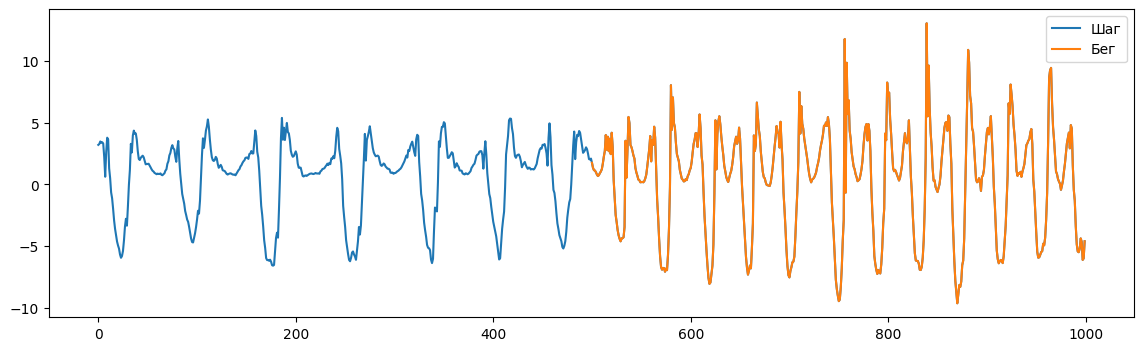

In [72]:
fig, ax =  plt.subplots(figsize=(14,4),ncols=1,nrows=1)
plt.plot(data[:],label='Шаг')
plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')
plt.legend()

In [73]:
result={}
times={}

##### 3.1.2 Реализация полного перебора

Приводится пример кода для нахождения топ 5 диссонансов с помощью реализации полного перебора.
Вам необходимо добавить код для сбора времени обработки данных.

In [74]:
# from modules.saxpy.discord import find_discords_brute_force
start = time()
discords_brute_force= np.stack(find_discords_brute_force(data[:], 50, 5))
end = time()
times[0] = end-start

In [75]:
print(f"Время работы полного перебора: {times[0]:.4f} секунд")

Время работы полного перебора: 157.7298 секунд


##### 3.1.3 HotSAX

Используя [реализацию](https://github.com/seninp/saxpy/blob/master/saxpy/hotsax.py) найдите топ 5 диссонансов ряда.
Произведите замер времени работы.

In [76]:
start = time()
discords_HotSAX= np.stack(find_discords_hotsax(data[:], 50, 5))
end = time()
times[1] = end-start

In [77]:
print(f"Время работы HotSAX: {times[1]:.4f} секунд")

Время работы HotSAX: 3.2801 секунд


##### 3.1.4 Визаулизация

Вам необходимо реализовать код позволяющий:
1. Вывести на одном графике ряд и его диссонансы
2. Столбчатую диаграмму времени работы обоих алгоритмов
   
Постройте графики для обоих алгоритмов и сравните полученные результаты.

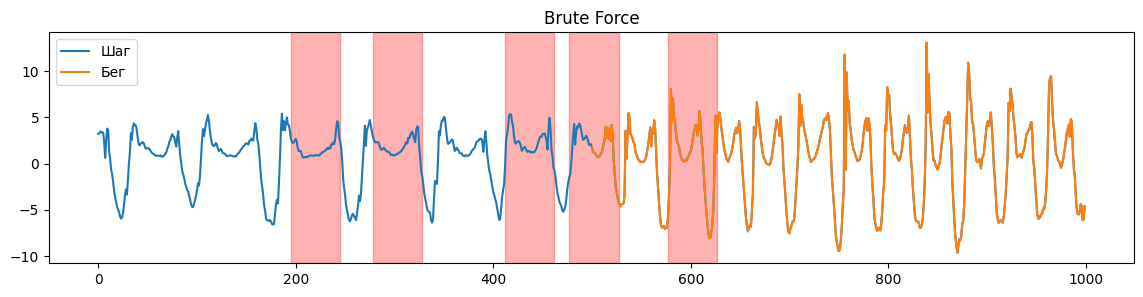

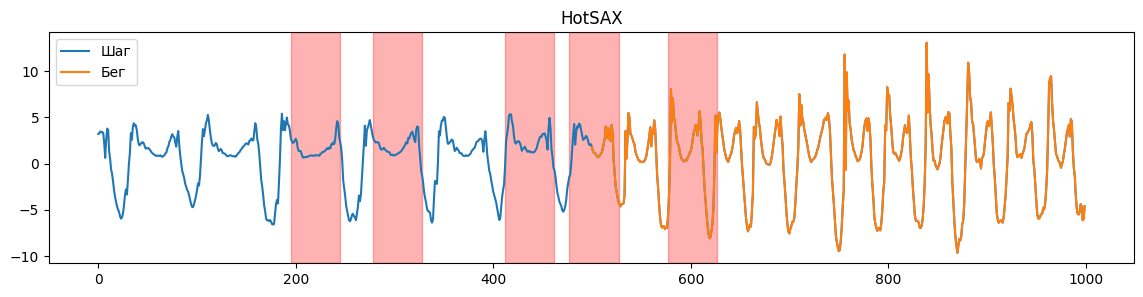

In [78]:
import matplotlib.pyplot as plt

# Функция для визуализации временного ряда с выделенными диссонансами
def plot_time_series_with_discords(data, discords, title):
    plt.figure(figsize=(14, 3))
    plt.plot(data[:],label='Шаг')
    plt.plot(np.arange(data.shape[0]//2,data.shape[0]),data[data.shape[0]//2:],label='Бег')

    # Выделяем диссонансы
    for idx, _ in discords:
        plt.axvspan(idx, idx + size_sub, color='red', alpha=0.3)

    plt.title(title)
    plt.legend()
    plt.show()

# Визуализация для полного перебора
plot_time_series_with_discords(data, discords_brute_force, 'Brute Force')

# Визуализация для HotSAX
plot_time_series_with_discords(data, discords_HotSAX, 'HotSAX')

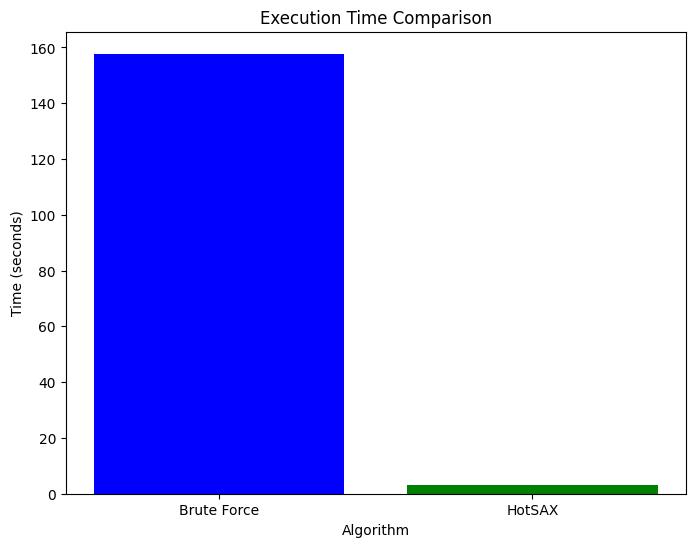

In [79]:
# Время работы алгоритмов
time_res = {
    'Brute Force': times[0],
    'HotSAX': times[1]  # Примерное время работы HotSAX
}

# Столбчатая диаграмма
plt.figure(figsize=(8, 6))
plt.bar(time_res.keys(), time_res.values(), color=['blue', 'green'])
plt.title('Execution Time Comparison')
plt.xlabel('Algorithm')
plt.ylabel('Time (seconds)')
plt.show()

##### 3.1.5 Такси NY

Произведите поиск диссонансов с помощью обоих алгоритмов на наборе данных, содержащим информацию о среднем числе пассажиров в NY. Отобразите найденные диссонансы обоими алгоритмами.

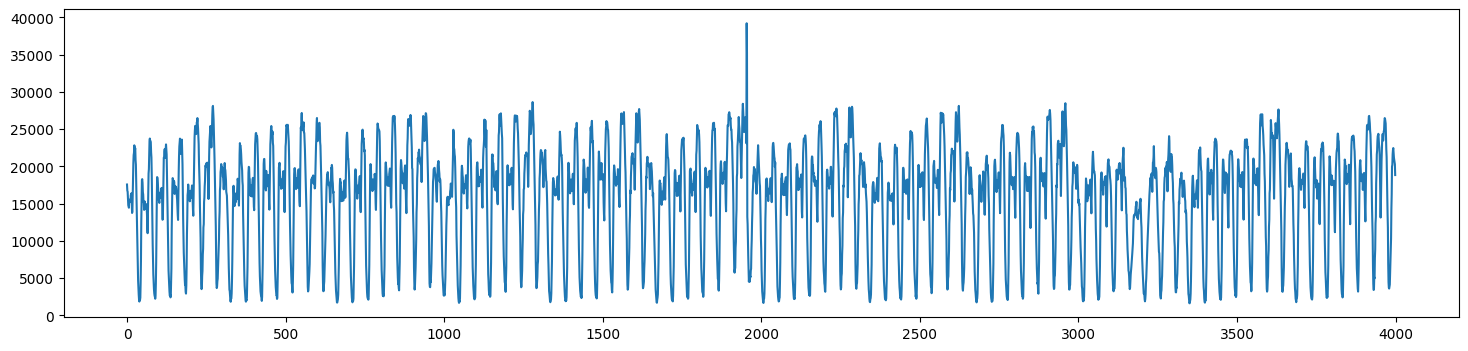

In [51]:
data_path = '/gdrive/My Drive/Colab Notebooks/АиПВРМИИ/03/nyc_taxi.csv' # для colab
nyc_taxi = pd.read_csv(data_path, index_col=0).values[4000:8000,0].astype(np.float64)
# nyc_taxi = pd.read_csv(dataset_dir_path/'nyc_taxi.csv',index_col=0).values[4000:8000,0].astype(np.float64) # для github
fig = plt.figure(figsize=(18, 4))
plt.plot(nyc_taxi)

Brute Force

In [59]:
start = time()
discords_brute_force= np.stack(find_discords_brute_force(nyc_taxi[:], 50, 5))
end = time()
times[0] = end-start

In [61]:
print(f"Время работы полного перебора: {times[0]:.4f} секунд")

Время работы полного перебора: 3791.8246 секунд


HotSAX

In [65]:
start = time()
discords_HotSAX= np.stack(find_discords_hotsax(nyc_taxi[:], 50, 5))
end = time()
times[1] = end-start

In [66]:
print(f"Время работы HotSAX: {times[1]:.4f} секунд")

Время работы HotSAX: 15.4371 секунд


Сравнение

/tmp/ipython-input-283844166.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


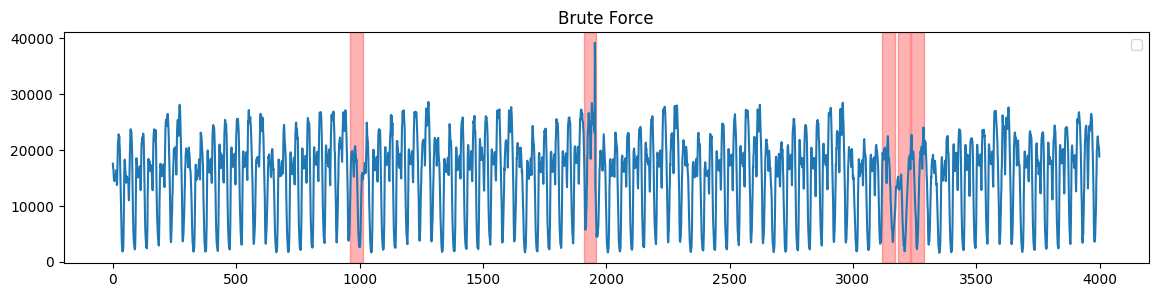

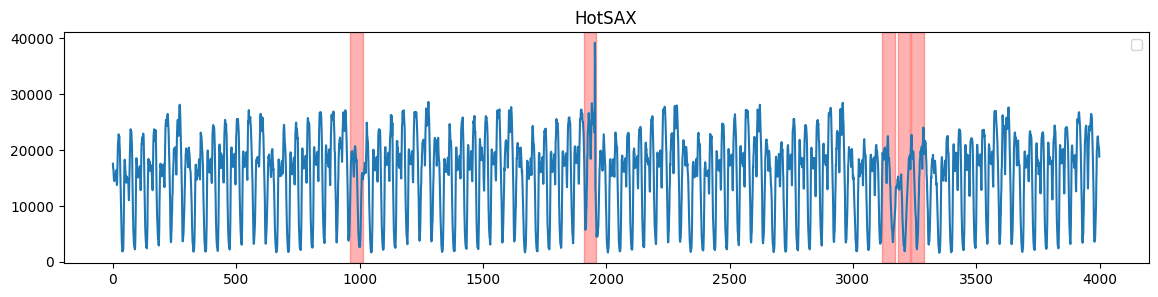

In [70]:
# Функция для визуализации временного ряда с выделенными диссонансами
def plot_time_series_with_discords(data, discords, title):
    plt.figure(figsize=(14, 3))
    plt.plot(data)

    # Выделяем диссонансы
    for idx, _ in discords:
        plt.axvspan(idx, idx + size_sub, color='red', alpha=0.3)

    plt.title(title)
    plt.legend()
    plt.show()

# Визуализация для полного перебора
plot_time_series_with_discords(nyc_taxi, discords_brute_force, 'Brute Force')

# Визуализация для HotSAX
plot_time_series_with_discords(nyc_taxi, discords_HotSAX, 'HotSAX')

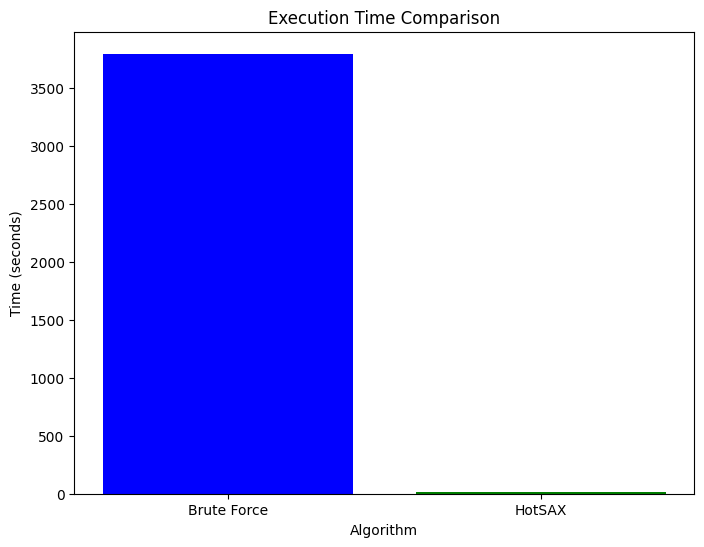

In [68]:
# Время работы алгоритмов
time_res = {
    'Brute Force': times[0],
    'HotSAX': times[1]  # Примерное время работы HotSAX
}

# Столбчатая диаграмма
plt.figure(figsize=(8, 6))
plt.bar(time_res.keys(), time_res.values(), color=['blue', 'green'])
plt.title('Execution Time Comparison')
plt.xlabel('Algorithm')
plt.ylabel('Time (seconds)')
plt.show()

# INSERT YOUR CODE

#### **3.2 Поиск диссонансов с помощью алгоритма DRAG**

In [ ]:
!pip install stumpy==1.11.1

In [ ]:
import stumpy
from stumpy import core, config
from stumpy.scrump import _prescrump


Как мы помним из лекций:

**Диапазонный диссонанс** – подпоследовательность ряда, расстояние от которой до ее ближайшего соседа не ниже заданного порога.

Основными параметрами при поисках диссонансов являются:
- $m$ - длина диссонанса
- $r$ - пороговое значение расстояния подпоследовательности ряда, до его ближайшего соседа


In [ ]:
from modules.drag import find_candidates, DRAG


Для поиска диссонансов в данной части практической работы мы воспользуемся алгоритмом **DRAG (Discord Range Aware Gathering)**.
Для начала воспользуемся данным алгоритмом, чтобы найти диссонансы в наборе данных содержащем активность человека.

In [ ]:
data = walk_run

Длину искомого диссонанса, как и для предыдущих алгоритмов, мы установим равно 50 точек.
Пороговое значение мы установим равным большим, чтобы узнать, как алгоритм отреагирует на большие значения данного параметра.

In [ ]:
m = 50
r = 10
idxs, _, _ = DRAG(data,m,r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 0


Как вы можете видеть мы установили слишком большое пороговое значение, алгоритму не удалось выделить ни одного диссонанса. Попробуем уменьшить пороговое значение до 1, чтобы улучшить результат.

In [ ]:
m = 50
r = 1
idxs, _, _ = DRAG(data, m, r)
print(f'Колличество найденных диссонансов: {len(idxs)}')

Колличество найденных диссонансов: 50


При такой комбинации параметров, улучшить ситуацию не получилось. Алгоритм выделил слишком большое количество диссонансов, часть которых является ложными диссонансами и не будут информативными для нас.

Произведите подобные эксперименты с набором данных такси NY. Постройте графики демонстрирующие найденные диссонансы. Пример Графика:
![second-graph](pics/fig_ex_2.png)

In [ ]:
# INSERT YOUR CODE

Чтобы разобраться, почему так происходит и как работает данный алгоритм, ниже мы реализуем все этапы алгоритма DRAG.

Как мы помним из лекций алгоритм DRAG содержит два этапа:

1. Отбор - За одно сканирование ряда сформировать множество кандидатов в диссонансы.
2. Очистка - За одно сканирование ряда отбросить кандидатов, которые являются ложными диссонансами.

##### 3.2.1 Отбор кандидатов

Первым этапом обработки данных является отбор множества потенциальных кандидатов. Мы выбираем из всего множества подпоследовательностей ряда такие, для которых расстояние до правых ближайших соседей больше параметра $r$.

In [ ]:
#выбирем более реальное значение для порога
r = 3

In [ ]:
T, M_T, Σ_T = core.preprocess(data, m)
#формируем массив длинной равной длине  исходного ряда - m + 1,
#элемент массива является истинным,
#в том случае если подпоследовательность является потенциальным кандидатом
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=None, right=True)
#находим индексы потенциальных кандидатов
cand_index = np.flatnonzero(is_cands)

In [ ]:
print(f'{len(cand_index)} {len(cand_index)/len(data)*100} %')

113 11.3 %


Во время отбора кандидатов нам удалось выделить около 113 подпоследовательностей(около 11.3%), которые мы бы могли назвать потенциальными диссонансами.
Это большой процент, который не может нас устраивать как конечный результат.
Если посмотреть на рисунок ниже, мы увидим, что большая часть потенциальных диссонансов расположена в районе смены активности.
К сожалению пресутсвуют и ложные диссонансы, которые случайным образом попали в данный список.

Сформируйте график найденных диссонансов

In [ ]:
# INSERT YOUR CODE

##### 3.2.2 Очистка кандидатов
Как уже упоминалось выше, 11.3% слишком большой процент диссонансов.
Для уменьшения числа потенциальных кандидатов произведем очистку от ложных диссонансов, путем сравнения расстояния до левых ближайших соседей потенциальных диссонансов с порогом $r$.


In [ ]:
is_cands = find_candidates(T, m, M_T, Σ_T, r, init_cands=is_cands, right=False)
cands = np.flatnonzero(is_cands)

In [ ]:
len(cands)/len(data)*100

2.9000000000000004

Сформируйте график найденных диссонансов

In [ ]:
# INSERT YOUR CODE

Нам удалось сократить число диссонансов до 2.9%. Если проанализировать рисунок, то можно заметить, что большая их часть является тривиальными повторениями подпоследовательности в области смены активности. На следующем шаге избавимся от них.

In [ ]:
from modules.drag import refine_candidates
discords_idx, discords_dist, discords_nn_idx = refine_candidates(T, m, M_T, Σ_T, is_cands)
len(discords_idx)/len(data)*100

0.8999999999999999

Сформируйте график найденных диссонансов

In [ ]:
# INSERT YOUR CODE

##### 3.2.3 Подбор параметров

Реализуйте перебор параметров $m$ и $r$. Подберете параметры таким образом, чтобы алгоритм обнаружил только те диссонансы, которые связаны со сменой активности. Сделайте вывод о том, как эти параметры влияют на качество работы модели.
Подберите оптимальные параметры алгоритма для набора данных такси NY.
Визуализируйте результаты для разных комбинаций. Сделайте выводы.


In [ ]:
# INSERT YOUR CODE

#### **3.3 Поиск диссонансов с помощью алгоритма Merlin**

Как мы уже выяснили подбирать параметры для DRAG простым перебором не очень удобно. Для оптимизации данного процесса в статье [1] был предложен алгоритм Merlin для оптимального поиска подходящего порогового значения.

Условно мы можем разделить поиск диссонансов на три шага:

1. Поиск диссонансов минимальной длинны $minL$. На данном шаге $r = 2\sqrt{minL}$.
2. Поиск диссонансов следующих четырех длин. На данном шаге $r = 0.99 \cdot nndist_{m-1}$. Где $nndist_{m-1}$ - расстояние до ближайшего соседа предыдущего найденного диссонанса.
3. Поиск диссонансов всех
оставшихся дли. $r = \mu - 2 \sigma$. Средние значение и стандартное отклонение вычисляются из расстояний 5 предыдущих диссонансов. н

[1] Nakamura T., Imamura M., Mercer R., Keogh E.J. MERLIN: parameter-free discovery of arbitrary length anomalies in massive time series archives. 20th IEEE Int. Conf. on Data Mining, ICDM 2020, Sorrento, Italy, November 17-20, 2020. pp. 1190-1195. IEEE (2020). https://doi.org/10.1109/ICDM50108.2020.00147

##### 3.3.1 Поиск диссонансов минимальной длинны

Вспомнил последовательность действий первого шага алгоритма:
![merlin-part-first](pics/first_part.png)

В данной работе мы внесем небольшое изменение, мы будем считать, что подпоследовательность может быть диссонансом только в том случае, если больше 75% точек, не входят в состав других диссонансов.

In [ ]:
T = walk_run
m = 50
# сформируем массив метод для потенциальных кандидатов в диссонансы.
# после каждого найденного диссонанса,
# мы будем исключать окружающие его подпоследовательности из числа потенциальных кандидатов,
# путем замены значений их меток на false
excl_zone = int(np.ceil(m / 4))
include = np.ones(len(T)-m+1, dtype=bool)
# Количество диссонансов, которые мы будем искать
topK = 10


In [ ]:
dis_idx = -np.ones((topK))
dis_nnDist = -np.ones((topK))
dis_nn_idx = np.full((topK),-np.inf)
#первое прближение r
r = 2*np.sqrt(m)
minL = m
maxL = int(m+np.ceil(m*0.1))
#количество найденных диссонасов
cound_find_dis = 0

while dis_nnDist[cound_find_dis-1]<0 and cound_find_dis<topK:
    result = DRAG(data=T,m=minL,r=r, include =include)
    for diss, nnDist, nn in zip(*result):
        dis_idx[cound_find_dis] = diss
        dis_nnDist[cound_find_dis] = nnDist
        dis_nn_idx[cound_find_dis] = nn
        #исключаем окружающие найденный диссонас
        #подпоследовательности и числа потенциальных диссонасов
        core.apply_exclusion_zone(include, diss, excl_zone, False)
        cound_find_dis+=1
        if cound_find_dis>=topK:
            break
    r*=0.5

In [ ]:
maxL

55

In [ ]:
print('Количество найденных на первом этапе диссонансов:', cound_find_dis)

Количество найденных на первом этапе диссонансов: 2


На первом шаге нам удалось выделить 2 диссонанса из 10 требуемых.
Реализуйте, оставшиеся шаги алгоритма, чтобы найти оставшиеся диссонансы.

![merlin-part-first](pics/second_part.png)


In [ ]:
# INSERT YOUR CODE

Найдите диссонансы набора такси NY. Визуализируйте найденные диссонансы для обоих наборов данных, сравните с результатами остальных методов.


In [ ]:
# INSERT YOUR CODE